# Notebook 06 — Baseline Traffic Signal Timing Strategy Evaluation

## Objective
Establish a transparent baseline fixed-time signal strategy to serve as the reference case for optimization and impact evaluation notebooks.

## Background / Context
Baseline timing provides the control scenario against which optimized strategies are judged. This notebook converts representative demand conditions into comparable capacity, queue-pressure, and delay-proxy outcomes.

## Methodology
The notebook loads prepared inputs, selects candidate intersections, defines baseline cycle and green splits, computes performance proxies, and summarizes results.

## Implementation
All steps below preserve the existing analytical logic while improving interpretability.

In [70]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})


## Implementation — Load Datasets

In [71]:
project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent

features_path = project_root / 'data' / 'processed' / 'signal_optimization_features_2015_2019.csv'
metrics_path = project_root / 'data' / 'processed' / 'signal_performance_metrics_2015_2019.csv'
output_path = project_root / 'data' / 'processed' / 'baseline_signal_timing_results.csv'

features_df = pd.read_csv(features_path, parse_dates=['date'])
metrics_df = pd.read_csv(metrics_path)

print(f'Features dataset shape: {features_df.shape}')
print(f'Metrics dataset shape: {metrics_df.shape}')

print()
print('Features preview:')
display(features_df.head())

print('Metrics preview:')
display(metrics_df.head())

Features dataset shape: (138672, 36)
Metrics dataset shape: (357, 14)

Features preview:


,location_id,location_name,centreline_id,direction,date,hour,traffic_latitude,traffic_longitude,nearest_signal_id,nearest_signal_name,nearest_signal_latitude,nearest_signal_longitude,distance_to_signal_m,is_signalized_match,year,month,quarter,day_of_week,is_weekend,hour_of_day,AM_peak_flag,PM_peak_flag,daily_total_volume,hourly_volume,peak_hour_volume,peak_ratio,hourly_share_of_daily_volume,normalized_demand_intensity,estimated_arrival_rate_vph,approach_demand_proxy,directional_imbalance,green_split_weight_proxy,critical_flow_proxy,saturation_proxy,is_peak_hour,observed_hour_count
0,10010625_WB,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015-05-14,2015-05-14 00:00:00,43.68,-79.34,"10,010,625.00",DANFORTH AVE / DONLANDS AVE,43.68,-79.34,82.78,True,2015,5,2,3,0,0,0,0,17031,286,1809,0.11,0.02,0.51,286,286,1.00,0.02,0.16,0.16,0,24
1,10010625_WB,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015-05-14,2015-05-14 01:00:00,43.68,-79.34,"10,010,625.00",DANFORTH AVE / DONLANDS AVE,43.68,-79.34,82.78,True,2015,5,2,3,0,1,0,0,17031,198,1809,0.11,0.01,0.35,198,198,1.00,0.01,0.11,0.11,0,24
2,10010625_WB,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015-05-14,2015-05-14 02:00:00,43.68,-79.34,"10,010,625.00",DANFORTH AVE / DONLANDS AVE,43.68,-79.34,82.78,True,2015,5,2,3,0,2,0,0,17031,134,1809,0.11,0.01,0.24,134,134,1.00,0.01,0.07,0.07,0,24
3,10010625_WB,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015-05-14,2015-05-14 03:00:00,43.68,-79.34,"10,010,625.00",DANFORTH AVE / DONLANDS AVE,43.68,-79.34,82.78,True,2015,5,2,3,0,3,0,0,17031,118,1809,0.11,0.01,0.21,118,118,1.00,0.01,0.07,0.07,0,24
4,10010625_WB,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015-05-14,2015-05-14 04:00:00,43.68,-79.34,"10,010,625.00",DANFORTH AVE / DONLANDS AVE,43.68,-79.34,82.78,True,2015,5,2,3,0,4,0,0,17031,131,1809,0.11,0.01,0.23,131,131,1.00,0.01,0.07,0.07,0,24


Metrics preview:


,nearest_signal_id,nearest_signal_name,avg_hourly_volume,peak_hour_volume,min_hourly_volume,hourly_volume_std,observation_count,avg_match_distance_m,active_days,avg_daily_volume,peak_to_average_ratio,traffic_variability_index,intersection_load_index,peak_load_index
0,436631,YONGE ST / STEELES AVE,"1,294.99",2418,80,706.18,144,46.10,3,"31,079.83",1.87,0.55,2.84,2.11
1,12377332,EGLINTON AVE W / MARTIN GROVE RD,"1,231.19",2621,82,761.43,168,79.23,7,"29,548.57",2.13,0.62,2.70,2.29
2,3327208,STEELES AVE W / DUFFERIN ST,"1,046.38",2249,63,589.74,144,2.68,3,"25,113.17",2.15,0.56,2.30,1.97
3,909165,DIXON RD / 427 N DIXON RAMP / PRIVATE ACCESS,"1,035.73",2447,81,653.10,144,91.08,3,"24,857.50",2.36,0.63,2.27,2.14
4,913150,DUNDAS ST W / NEILSON DR / WEST MALL CRES,"1,004.21",2290,50,659.40,480,58.13,10,"24,101.05",2.28,0.66,2.21,2.00


## Implementation — Validate Required Columns

In [72]:
required_feature_columns = [
    'nearest_signal_id',
    'is_signalized_match',
    'hourly_volume',
    'peak_hour_volume',
]

optional_feature_columns = ['nearest_signal_name']

required_metric_columns = [
    'nearest_signal_id',
    'avg_hourly_volume',
    'peak_hour_volume',
    'intersection_load_index',
]

if 'nearest_signal_name' in metrics_df.columns:
    required_metric_columns.append('nearest_signal_name')

missing_feature_columns = sorted(set(required_feature_columns) - set(features_df.columns))
missing_metric_columns = sorted(set(required_metric_columns) - set(metrics_df.columns))

if missing_feature_columns:
    raise KeyError(f'Missing required columns in features dataset: {missing_feature_columns}')

if missing_metric_columns:
    raise KeyError(f'Missing required columns in metrics dataset: {missing_metric_columns}')

available_optional_feature_columns = [
    column for column in optional_feature_columns if column in features_df.columns
]

print('Required columns are available.')
if available_optional_feature_columns:
    print(f'Optional descriptive columns available in features dataset: {available_optional_feature_columns}')

Required columns are available.
Optional descriptive columns available in features dataset: ['nearest_signal_name']


## Implementation — Select Candidate Intersections

In [73]:
top_n = 5

ranked_metrics_df = metrics_df.copy()
rank_columns = ['avg_hourly_volume', 'peak_hour_volume', 'intersection_load_index']

for column in rank_columns:
    ranked_metrics_df[f'{column}_rank'] = ranked_metrics_df[column].rank(method='dense', ascending=False)

ranked_metrics_df['composite_rank_score'] = ranked_metrics_df[
    [f'{column}_rank' for column in rank_columns]
].sum(axis=1)

selected_intersections_df = (
    ranked_metrics_df
    .sort_values(
        by=['composite_rank_score', 'intersection_load_index', 'peak_hour_volume', 'avg_hourly_volume'],
        ascending=[True, False, False, False],
    )
    .head(top_n)
    .reset_index(drop=True)
)

selection_columns = [
    'nearest_signal_id',
    'nearest_signal_name',
    'avg_hourly_volume',
    'peak_hour_volume',
    'intersection_load_index',
    'composite_rank_score',
]

display(selected_intersections_df[selection_columns])

,nearest_signal_id,nearest_signal_name,avg_hourly_volume,peak_hour_volume,intersection_load_index,composite_rank_score
0,12377332,EGLINTON AVE W / MARTIN GROVE RD,"1,231.19",2621,2.70,6.00
1,436631,YONGE ST / STEELES AVE,"1,294.99",2418,2.84,7.00
2,909165,DIXON RD / 427 N DIXON RAMP / PRIVATE ACCESS,"1,035.73",2447,2.27,12.00
3,3327208,STEELES AVE W / DUFFERIN ST,"1,046.38",2249,2.30,15.00
4,821,MILLWOOD RD / VILLAGE STATION RD / REDWAY RD,965.31,3047,2.12,15.00


## Implementation — Estimate Demand for Selected Intersections

In [74]:
scenario_records = []

for _, row in selected_intersections_df.iterrows():
    scenario_records.append({
        'nearest_signal_id': row['nearest_signal_id'],
        'nearest_signal_name': row.get('nearest_signal_name', f"Signal {int(row['nearest_signal_id'])}"),
        'scenario_label': 'average-demand',
        'hourly_demand': row['avg_hourly_volume'],
        'representative_peak_demand': row['peak_hour_volume'],
    })
    scenario_records.append({
        'nearest_signal_id': row['nearest_signal_id'],
        'nearest_signal_name': row.get('nearest_signal_name', f"Signal {int(row['nearest_signal_id'])}"),
        'scenario_label': 'peak-demand',
        'hourly_demand': row['peak_hour_volume'],
        'representative_peak_demand': row['peak_hour_volume'],
    })

scenario_df = pd.DataFrame(scenario_records)
display(scenario_df)

,nearest_signal_id,nearest_signal_name,scenario_label,hourly_demand,representative_peak_demand
0,12377332,EGLINTON AVE W / MARTIN GROVE RD,average-demand,"1,231.19",2621
1,12377332,EGLINTON AVE W / MARTIN GROVE RD,peak-demand,"2,621.00",2621
2,436631,YONGE ST / STEELES AVE,average-demand,"1,294.99",2418
3,436631,YONGE ST / STEELES AVE,peak-demand,"2,418.00",2418
4,909165,DIXON RD / 427 N DIXON RAMP / PRIVATE ACCESS,average-demand,"1,035.73",2447
5,909165,DIXON RD / 427 N DIXON RAMP / PRIVATE ACCESS,peak-demand,"2,447.00",2447
6,3327208,STEELES AVE W / DUFFERIN ST,average-demand,"1,046.38",2249
7,3327208,STEELES AVE W / DUFFERIN ST,peak-demand,"2,249.00",2249
8,821,MILLWOOD RD / VILLAGE STATION RD / REDWAY RD,average-demand,965.31,3047
9,821,MILLWOOD RD / VILLAGE STATION RD / REDWAY RD,peak-demand,"3,047.00",3047


## Implementation — Define Baseline Timing Assumptions
The baseline strategy uses fixed cycle length and fixed green allocation across scenarios. This is intentionally simple and operationally interpretable.

Limitations of this baseline setup:
- It does not adapt green allocation to short-term demand fluctuations.
- It may underperform under high congestion where directional imbalance changes quickly.
- It is best treated as a benchmark rather than a final control policy.

In [75]:
baseline_cycle_length_sec = 90
lost_time_sec = 10
effective_green_sec = baseline_cycle_length_sec - lost_time_sec

green_split_phase_a = 0.50
green_split_phase_b = 0.50

green_time_phase_a_sec = effective_green_sec * green_split_phase_a
green_time_phase_b_sec = effective_green_sec * green_split_phase_b

baseline_assumptions_df = pd.DataFrame({
    'parameter': [
        'baseline_cycle_length_sec',
        'lost_time_sec',
        'effective_green_sec',
        'green_split_phase_a',
        'green_split_phase_b',
        'green_time_phase_a_sec',
        'green_time_phase_b_sec',
    ],
    'value': [
        baseline_cycle_length_sec,
        lost_time_sec,
        effective_green_sec,
        green_split_phase_a,
        green_split_phase_b,
        green_time_phase_a_sec,
        green_time_phase_b_sec,
    ]
})

display(baseline_assumptions_df)

,parameter,value
0,baseline_cycle_length_sec,90.00
1,lost_time_sec,10.00
2,effective_green_sec,80.00
3,green_split_phase_a,0.50
4,green_split_phase_b,0.50
5,green_time_phase_a_sec,40.00
6,green_time_phase_b_sec,40.00


## Results — Estimate Baseline Traffic Flow Performance
Performance metrics are computed as simplified operational proxies under baseline timing. These results establish the benchmark that optimization notebooks attempt to improve.

In [76]:
saturation_flow_per_hour = 1800

capacity_phase_a_per_hour = saturation_flow_per_hour * (green_time_phase_a_sec / baseline_cycle_length_sec)
capacity_phase_b_per_hour = saturation_flow_per_hour * (green_time_phase_b_sec / baseline_cycle_length_sec)
baseline_total_capacity_per_hour = capacity_phase_a_per_hour + capacity_phase_b_per_hour

results_df = scenario_df.copy()
results_df['baseline_cycle_length_sec'] = baseline_cycle_length_sec
results_df['lost_time_sec'] = lost_time_sec
results_df['effective_green_sec'] = effective_green_sec
results_df['green_time_phase_a_sec'] = green_time_phase_a_sec
results_df['green_time_phase_b_sec'] = green_time_phase_b_sec
results_df['capacity_phase_a_per_hour'] = capacity_phase_a_per_hour
results_df['capacity_phase_b_per_hour'] = capacity_phase_b_per_hour
results_df['baseline_total_capacity_per_hour'] = baseline_total_capacity_per_hour
results_df['throughput_proxy'] = np.minimum(
    results_df['hourly_demand'],
    results_df['baseline_total_capacity_per_hour'],
)
results_df['queue_pressure_proxy'] = np.maximum(
    0,
    results_df['hourly_demand'] - results_df['baseline_total_capacity_per_hour'],
)
results_df['delay_proxy'] = (
    results_df['queue_pressure_proxy'] / results_df['hourly_demand'].clip(lower=1)
)

results_df = results_df[[
    'nearest_signal_id',
    'nearest_signal_name',
    'scenario_label',
    'hourly_demand',
    'baseline_cycle_length_sec',
    'lost_time_sec',
    'effective_green_sec',
    'green_time_phase_a_sec',
    'green_time_phase_b_sec',
    'capacity_phase_a_per_hour',
    'capacity_phase_b_per_hour',
    'baseline_total_capacity_per_hour',
    'throughput_proxy',
    'queue_pressure_proxy',
    'delay_proxy',
]].sort_values(['scenario_label', 'hourly_demand'], ascending=[True, False]).reset_index(drop=True)

display(results_df)

,nearest_signal_id,nearest_signal_name,scenario_label,hourly_demand,baseline_cycle_length_sec,lost_time_sec,effective_green_sec,green_time_phase_a_sec,green_time_phase_b_sec,capacity_phase_a_per_hour,capacity_phase_b_per_hour,baseline_total_capacity_per_hour,throughput_proxy,queue_pressure_proxy,delay_proxy
0,436631,YONGE ST / STEELES AVE,average-demand,"1,294.99",90,10,80,40.00,40.00,800.00,800.00,"1,600.00","1,294.99",0.00,0.00
1,12377332,EGLINTON AVE W / MARTIN GROVE RD,average-demand,"1,231.19",90,10,80,40.00,40.00,800.00,800.00,"1,600.00","1,231.19",0.00,0.00
2,3327208,STEELES AVE W / DUFFERIN ST,average-demand,"1,046.38",90,10,80,40.00,40.00,800.00,800.00,"1,600.00","1,046.38",0.00,0.00
3,909165,DIXON RD / 427 N DIXON RAMP / PRIVATE ACCESS,average-demand,"1,035.73",90,10,80,40.00,40.00,800.00,800.00,"1,600.00","1,035.73",0.00,0.00
4,821,MILLWOOD RD / VILLAGE STATION RD / REDWAY RD,average-demand,965.31,90,10,80,40.00,40.00,800.00,800.00,"1,600.00",965.31,0.00,0.00
5,821,MILLWOOD RD / VILLAGE STATION RD / REDWAY RD,peak-demand,"3,047.00",90,10,80,40.00,40.00,800.00,800.00,"1,600.00","1,600.00","1,447.00",0.47
6,12377332,EGLINTON AVE W / MARTIN GROVE RD,peak-demand,"2,621.00",90,10,80,40.00,40.00,800.00,800.00,"1,600.00","1,600.00","1,021.00",0.39
7,909165,DIXON RD / 427 N DIXON RAMP / PRIVATE ACCESS,peak-demand,"2,447.00",90,10,80,40.00,40.00,800.00,800.00,"1,600.00","1,600.00",847.00,0.35
8,436631,YONGE ST / STEELES AVE,peak-demand,"2,418.00",90,10,80,40.00,40.00,800.00,800.00,"1,600.00","1,600.00",818.00,0.34
9,3327208,STEELES AVE W / DUFFERIN ST,peak-demand,"2,249.00",90,10,80,40.00,40.00,800.00,800.00,"1,600.00","1,600.00",649.00,0.29


## Results — Create Results Table

In [77]:
print(f'Final results table shape: {results_df.shape}')
display(results_df)

Final results table shape: (10, 15)


,nearest_signal_id,nearest_signal_name,scenario_label,hourly_demand,baseline_cycle_length_sec,lost_time_sec,effective_green_sec,green_time_phase_a_sec,green_time_phase_b_sec,capacity_phase_a_per_hour,capacity_phase_b_per_hour,baseline_total_capacity_per_hour,throughput_proxy,queue_pressure_proxy,delay_proxy
0,436631,YONGE ST / STEELES AVE,average-demand,"1,294.99",90,10,80,40.00,40.00,800.00,800.00,"1,600.00","1,294.99",0.00,0.00
1,12377332,EGLINTON AVE W / MARTIN GROVE RD,average-demand,"1,231.19",90,10,80,40.00,40.00,800.00,800.00,"1,600.00","1,231.19",0.00,0.00
2,3327208,STEELES AVE W / DUFFERIN ST,average-demand,"1,046.38",90,10,80,40.00,40.00,800.00,800.00,"1,600.00","1,046.38",0.00,0.00
3,909165,DIXON RD / 427 N DIXON RAMP / PRIVATE ACCESS,average-demand,"1,035.73",90,10,80,40.00,40.00,800.00,800.00,"1,600.00","1,035.73",0.00,0.00
4,821,MILLWOOD RD / VILLAGE STATION RD / REDWAY RD,average-demand,965.31,90,10,80,40.00,40.00,800.00,800.00,"1,600.00",965.31,0.00,0.00
5,821,MILLWOOD RD / VILLAGE STATION RD / REDWAY RD,peak-demand,"3,047.00",90,10,80,40.00,40.00,800.00,800.00,"1,600.00","1,600.00","1,447.00",0.47
6,12377332,EGLINTON AVE W / MARTIN GROVE RD,peak-demand,"2,621.00",90,10,80,40.00,40.00,800.00,800.00,"1,600.00","1,600.00","1,021.00",0.39
7,909165,DIXON RD / 427 N DIXON RAMP / PRIVATE ACCESS,peak-demand,"2,447.00",90,10,80,40.00,40.00,800.00,800.00,"1,600.00","1,600.00",847.00,0.35
8,436631,YONGE ST / STEELES AVE,peak-demand,"2,418.00",90,10,80,40.00,40.00,800.00,800.00,"1,600.00","1,600.00",818.00,0.34
9,3327208,STEELES AVE W / DUFFERIN ST,peak-demand,"2,249.00",90,10,80,40.00,40.00,800.00,800.00,"1,600.00","1,600.00",649.00,0.29


## Results — Visualize Baseline Results

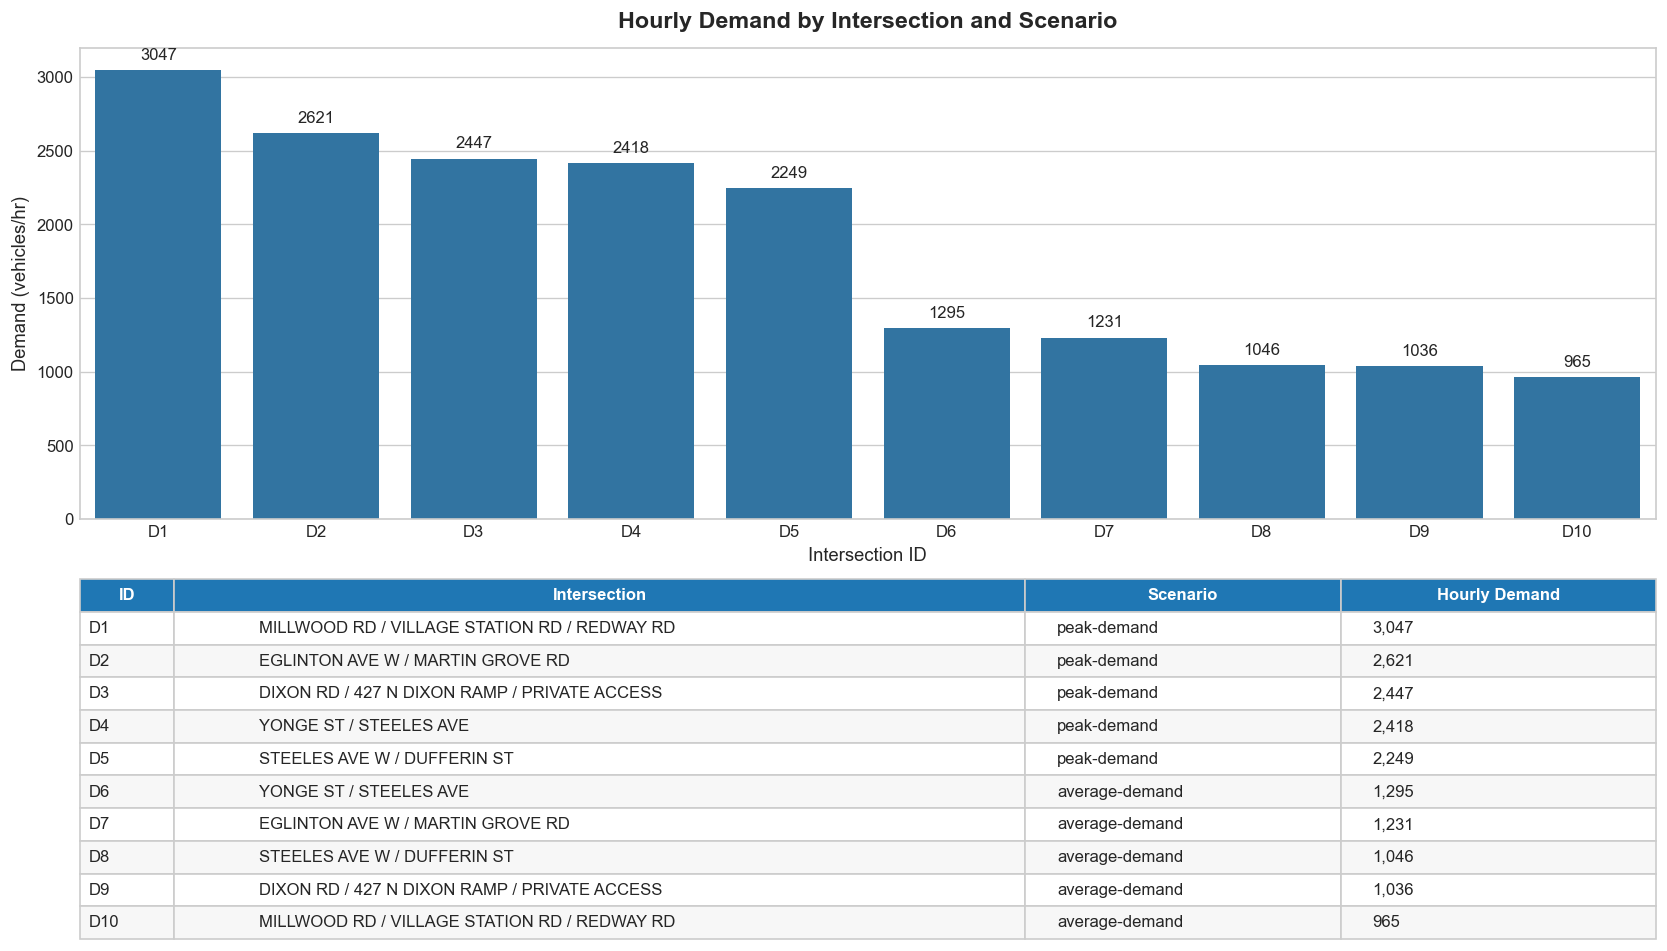

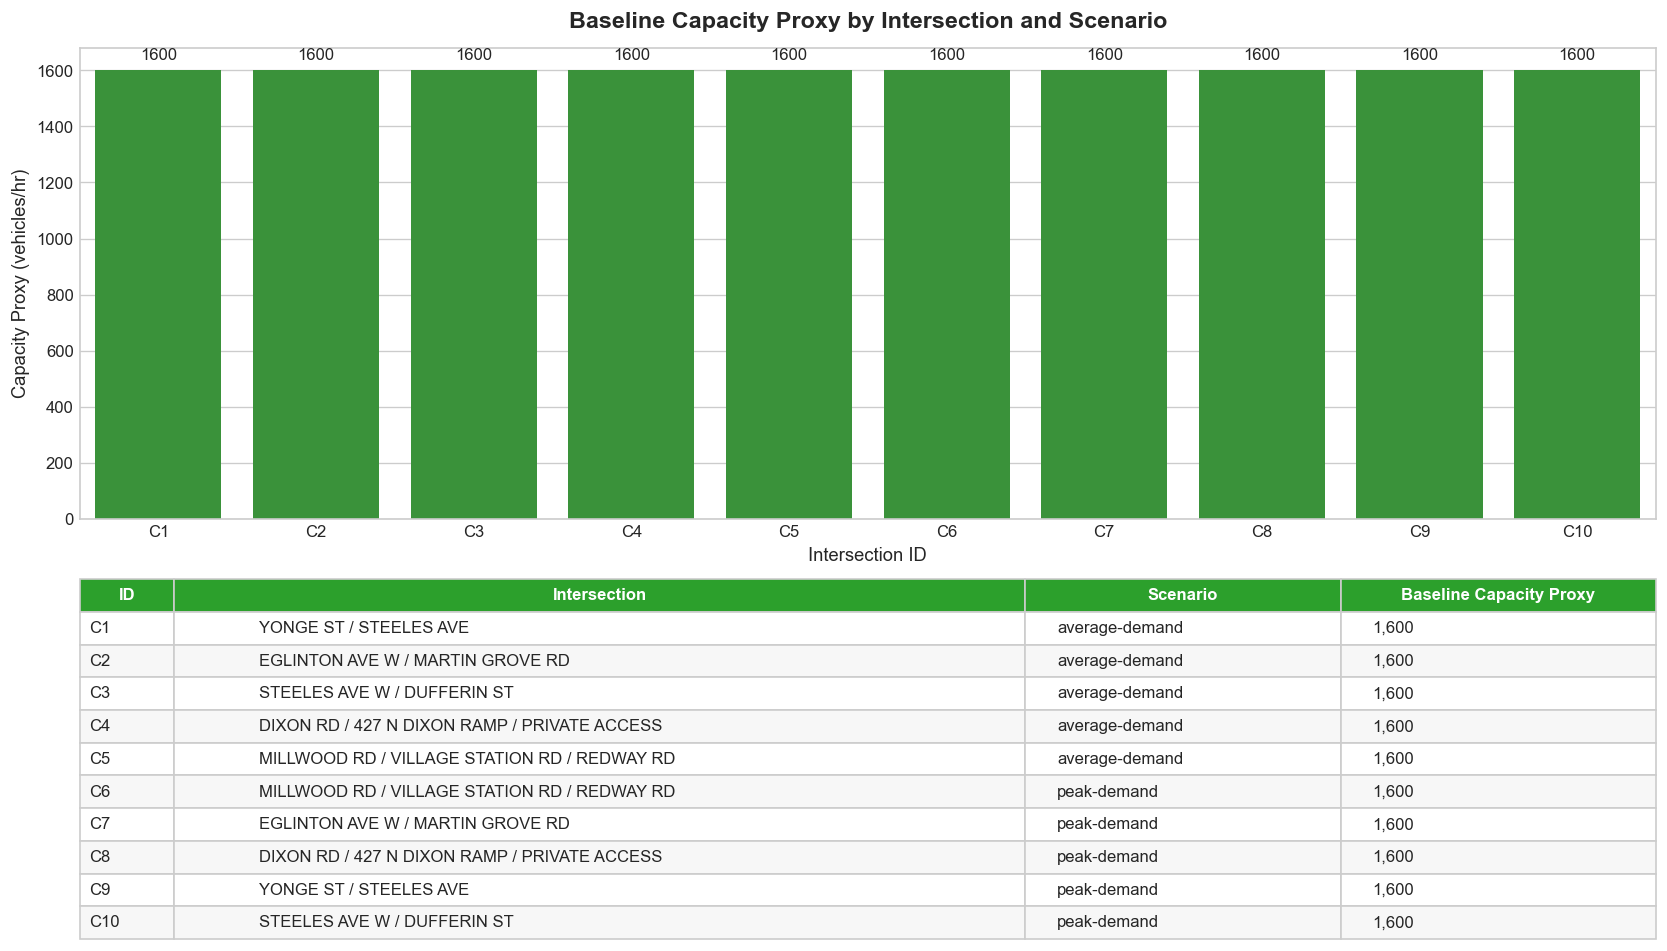

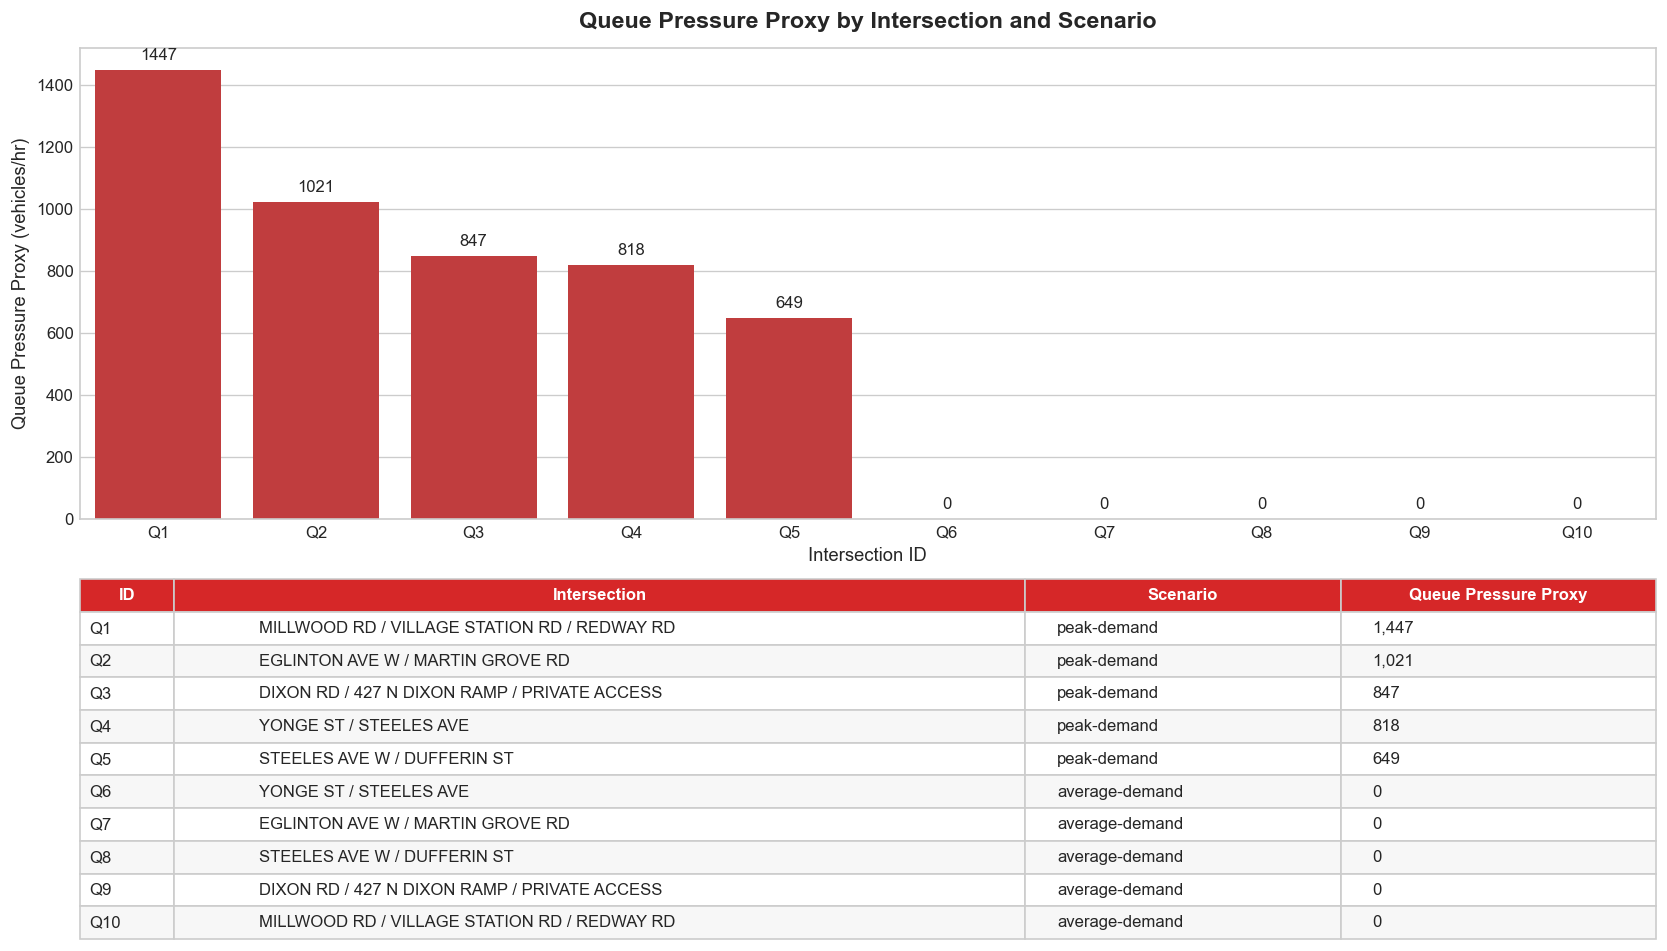

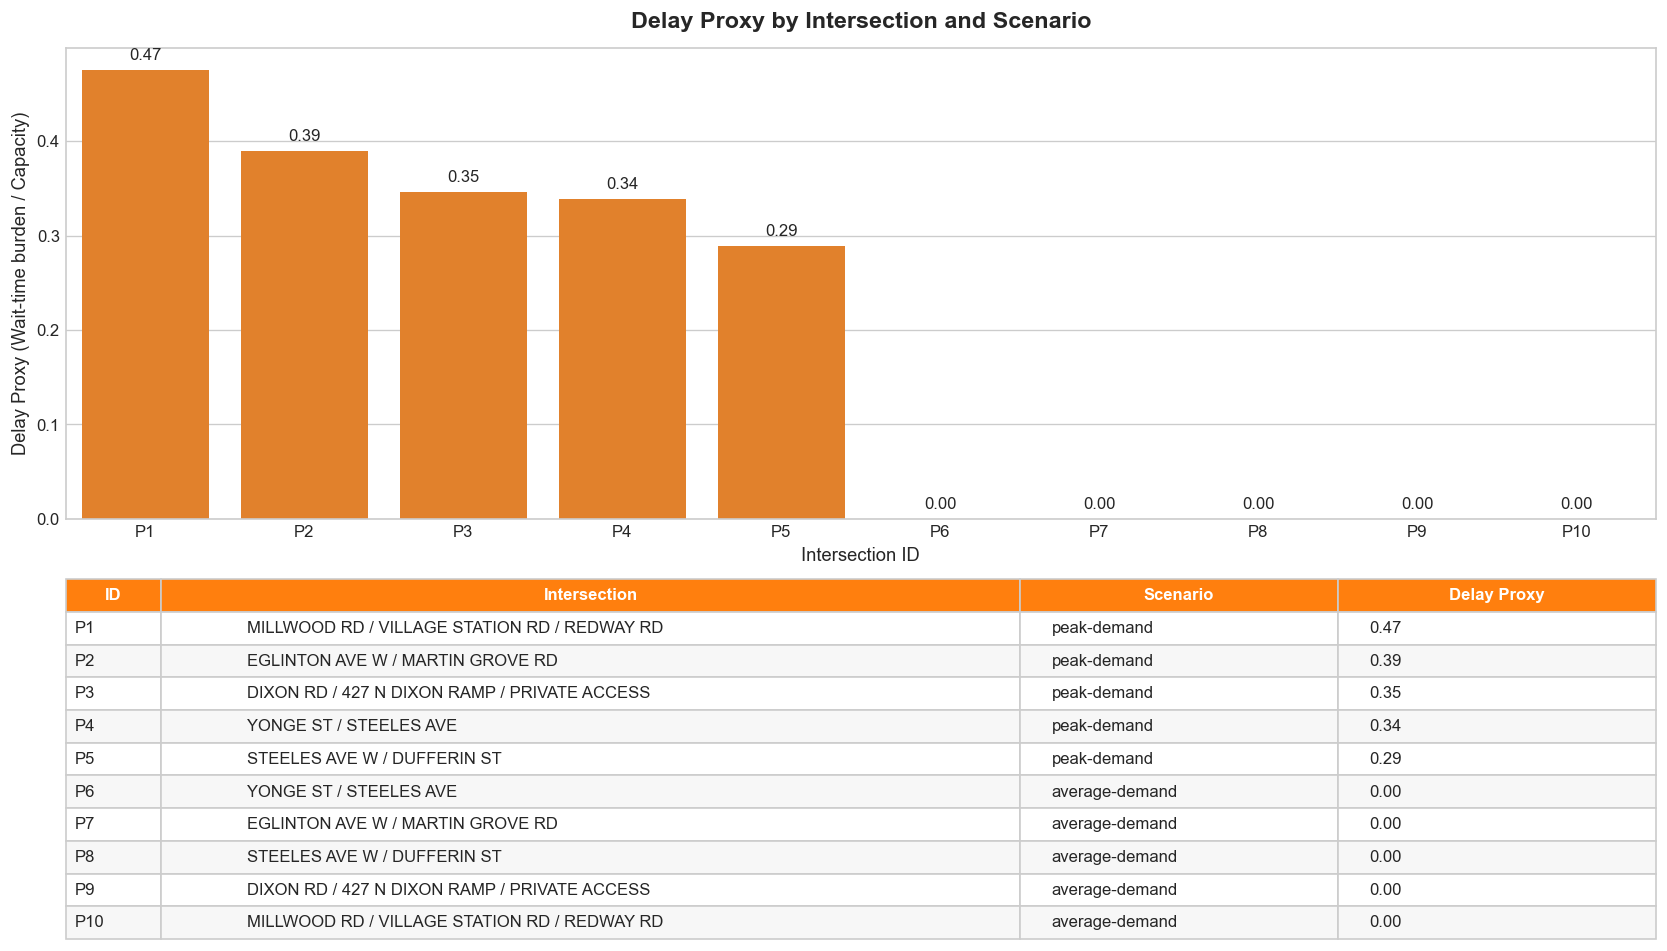

In [78]:
import seaborn as sns
def plot_with_table(df, metric_col, title, ylabel, color, id_prefix="S"):
    # Sort and label
    df_sorted = df.sort_values(metric_col, ascending=False).reset_index(drop=True)
    short_labels = [f"{id_prefix}{i+1}" for i in range(len(df_sorted))]
    
    # Format the df_sorted for labels
    df_sorted["label"] = short_labels
    
    fig, (ax_chart, ax_tbl) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [3, 2]}, tight_layout=True)

    # Plot
    sns.barplot(data=df_sorted, x="label", y=metric_col, color=color, ax=ax_chart)
    ax_chart.set_title(title, pad=12, fontsize=14, fontweight="bold")
    ax_chart.set_xlabel("Intersection ID")
    ax_chart.set_ylabel(ylabel)
    
    # Add values on top of bars
    for p in ax_chart.patches:
        ax_chart.annotate(
            format(p.get_height(), ".2f" if "Proxy" in title and "Delay" in title else ".0f"), 
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha="center", va="center", xytext=(0, 9), textcoords="offset points", fontsize=10
        )

    # Table
    ax_tbl.axis("off")
    
    # Cap intersection names to prevent giant multiline wrapping in table
    table_data = []
    for i in range(len(df_sorted)):
        name = df_sorted.loc[i, "nearest_signal_name"]
        if str(name) == "nan": name = str(df_sorted.loc[i, "nearest_signal_id"])
        scenario = df_sorted.loc[i, "scenario_label"]
        val = df_sorted.loc[i, metric_col]
        val_str = f"{val:,.2f}" if "Proxy" in title and "Delay" in title else f"{val:,.0f}"
        table_data.append([short_labels[i], name, scenario, val_str])
        
    tbl = ax_tbl.table(
        cellText=table_data, colLabels=["ID", "Intersection", "Scenario", title.split("by")[0].strip()],
        loc="center", cellLoc="left", colWidths=[0.06, 0.54, 0.20, 0.20]
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.4)
    
    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor("#cccccc")
        if row == 0:
            cell.set_facecolor(color)
            cell.set_text_props(color="white", fontweight="bold")
        else:
            cell.set_facecolor("#f7f7f7" if row % 2 == 0 else "white")
            
    plt.show()

# 1. Hourly Demand
plot_with_table(
    results_df, "hourly_demand", "Hourly Demand by Intersection and Scenario", 
    "Demand (vehicles/hr)", "#1f77b4", "D"
)

# 2. Capacity Proxy
plot_with_table(
    results_df, "baseline_total_capacity_per_hour", "Baseline Capacity Proxy by Intersection and Scenario", 
    "Capacity Proxy (vehicles/hr)", "#2ca02c", "C"
)

# 3. Queue Pressure Proxy
plot_with_table(
    results_df, "queue_pressure_proxy", "Queue Pressure Proxy by Intersection and Scenario", 
    "Queue Pressure Proxy (vehicles/hr)", "#d62728", "Q"
)

# 4. Delay Proxy
plot_with_table(
    results_df, "delay_proxy", "Delay Proxy by Intersection and Scenario", 
    "Delay Proxy (Wait-time burden / Capacity)", "#ff7f0e", "P"
)


The baseline charts show how demand, capacity proxy, queue pressure, and delay proxy vary by intersection and scenario. They provide the benchmark profile needed for fair baseline-versus-optimized comparison.

## Save Results

The final baseline timing results are exported to the processed data directory so they can be reused in later optimization and simulation notebooks.

In [79]:
output_path.parent.mkdir(parents=True, exist_ok=True)
results_df.to_csv(output_path, index=False)
print(f'Baseline timing results saved to: {output_path}')

Baseline timing results saved to: /Users/manavparikh/Documents/GitHub/unfc-capstone-traffic-forecasting/data/processed/baseline_signal_timing_results.csv


## Conclusion / Key Takeaways
- A fixed-time baseline strategy was defined and evaluated across representative scenarios.
- Baseline green splits and cycle assumptions were made explicit for reproducibility.
- Results provide a defensible benchmark for later optimization and impact-assessment stages.
- Subsequent notebooks evaluate whether demand-responsive timing materially outperforms this baseline.